# Static Landslide Susceptibility Modelling

This notebook develops and evaluates a static landslide susceptibility model for Sri Lanka using soil and geographic variables. The workflow covers data quality assessment, exploratory analysis, model comparison, spatial validation, threshold analysis, calibration, risk categorisation, and final performance reporting.

## 1. Import Libraries and Configure the Analysis

In [11]:
import pandas as pd

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
sns.set_theme(style='whitegrid')

## 2. Load the Raw Static Dataset

In [13]:

df = pd.read_csv("../data/raw/landslide_static_model_dataset.csv")

print(df.shape)
display(df.head())

(5597, 17)


,label,fold,block_id,soil_clay_0_30,soil_sand_0_30,soil_silt_0_30,soil_oc_0_30,soil_ph_0_30,soil_bd_0_30,soil_awc_0_30,soil_clay_gradient,soil_cec_0_30,soil_clay_60_100,bench_lhmp_class,diag_nearest_gauge_km,meta_lat,meta_lon
0,1,4,66_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.70095,7.098072,80.756045
1,1,4,65_70,23.84051,54.35036,20.01871,1.51113,5.39450,1.25873,0.05892,8.00685,14.15983,29.81838,3.0,1.07428,7.109057,80.746482
2,1,4,66_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.63560,7.099661,80.755744
3,1,4,65_70,23.99696,53.11716,20.90986,2.11253,5.33985,1.22577,0.06172,9.25907,15.30557,30.97781,2.0,0.39824,7.098072,80.753045
4,1,3,67_72,22.30682,57.88093,18.38064,1.51489,5.55341,1.28142,0.05545,7.89976,14.52311,28.72892,1.0,5.44532,7.151016,80.790857


In [14]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))
print(df.isnull().sum())
print(df['fold'].value_counts())

label
0    4398
1    1199
Name: count, dtype: int64
label
0    0.785778
1    0.214222
Name: proportion, dtype: float64
label                      0
fold                       0
block_id                   0
soil_clay_0_30             0
soil_sand_0_30             0
soil_silt_0_30             0
soil_oc_0_30               0
soil_ph_0_30               0
soil_bd_0_30               0
soil_awc_0_30              0
soil_clay_gradient         0
soil_cec_0_30              0
soil_clay_60_100           0
bench_lhmp_class         170
diag_nearest_gauge_km      0
meta_lat                   0
meta_lon                   0
dtype: int64
fold
0    1196
4    1150
1    1105
3    1094
2    1052
Name: count, dtype: int64


## 3. Assess Data Quality and Class Balance

In [15]:
print('landslide share:', round(df.label.mean(), 3))
print(df.label.value_counts())
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])

landslide share: 0.214
label
0    4398
1    1199
Name: count, dtype: int64

missing values:
bench_lhmp_class    170
dtype: int64


## 4. Inspect Existing Spatial Fold Assignments

In [16]:
blocks_in_many_folds = (df.groupby('block_id').fold.nunique() > 1).sum()
print('blocks in more than one fold:', blocks_in_many_folds)

df.groupby('fold').label.agg(rows='size', landslides='sum', share='mean').round(3)

blocks in more than one fold: 0


,rows,landslides,share
fold,,,
0,1196,212,0.177
1,1105,317,0.287
2,1052,143,0.136
3,1094,147,0.134
4,1150,380,0.330


## 5. Identify Duplicate Observations

In [66]:
print('exact duplicate rows:', df.duplicated().sum())
print('duplicates among landslides:', df[df.label == 1].duplicated().sum())
print('duplicates among non-landslides:', df[df.label == 0].duplicated().sum())

exact duplicate rows: 0
duplicates among landslides: 0
duplicates among non-landslides: 0


## 6. Remove Duplicate Observations

In [19]:
n_total = len(clean)
n_landslides = int(clean["label"].sum())
n_non_landslides = n_total - n_landslides
landslide_share = n_landslides / n_total

print(f"Total samples: {n_total:,}")
print(f"Landslides: {n_landslides:,}")
print(f"Non-landslides: {n_non_landslides:,}")
print(f"Landslide share: {landslide_share:.3%}")

display(
    clean["label"]
    .value_counts()
    .rename(index={0: "Non-landslide", 1: "Landslide"})
    .to_frame("Count")
)

Total samples: 5,437
Landslides: 1,039
Non-landslides: 4,398
Landslide share: 19.110%


,Count
label,
Non-landslide,4398
Landslide,1039


## 7. Define Feature Groups and Examine Relationships

['soil_clay_0_30', 'soil_sand_0_30', 'soil_silt_0_30', 'soil_oc_0_30', 'soil_ph_0_30', 'soil_bd_0_30', 'soil_awc_0_30', 'soil_clay_gradient', 'soil_cec_0_30', 'soil_clay_60_100']


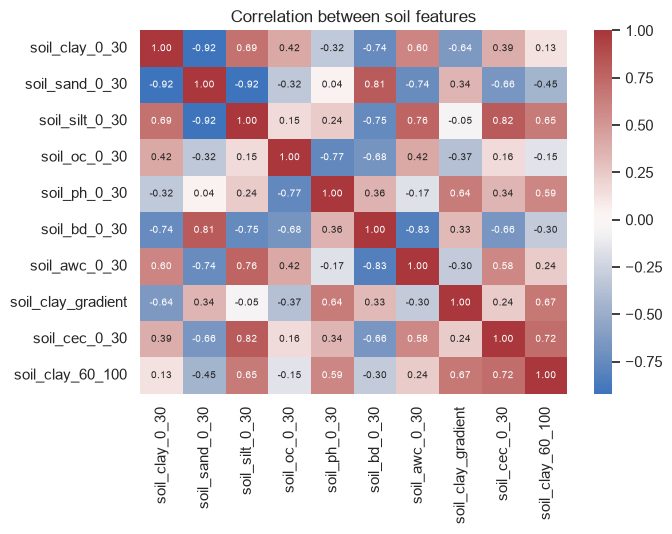

In [20]:
SOIL = [c for c in clean.columns if c.startswith('soil_')]
print(SOIL)

plt.figure(figsize=(7, 5.5))
sns.heatmap(clean[SOIL].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, annot_kws={'size': 7})
plt.title('Correlation between soil features')
plt.tight_layout()
plt.show()

In [21]:
print('unique soil vectors:', clean[SOIL].drop_duplicates().shape[0], 'of', len(clean), 'rows')

clean.groupby('label')[SOIL].mean().T.round(2)

unique soil vectors: 1570 of 5437 rows


label,0,1
soil_clay_0_30,22.74,22.90
soil_sand_0_30,57.61,57.21
soil_silt_0_30,18.35,18.65
soil_oc_0_30,2.08,2.05
soil_ph_0_30,5.29,5.31
soil_bd_0_30,1.23,1.22
soil_awc_0_30,0.06,0.06
soil_clay_gradient,5.27,5.55
soil_cec_0_30,14.19,14.51
soil_clay_60_100,26.31,27.02


## 8. Compare Feature Distributions by Class

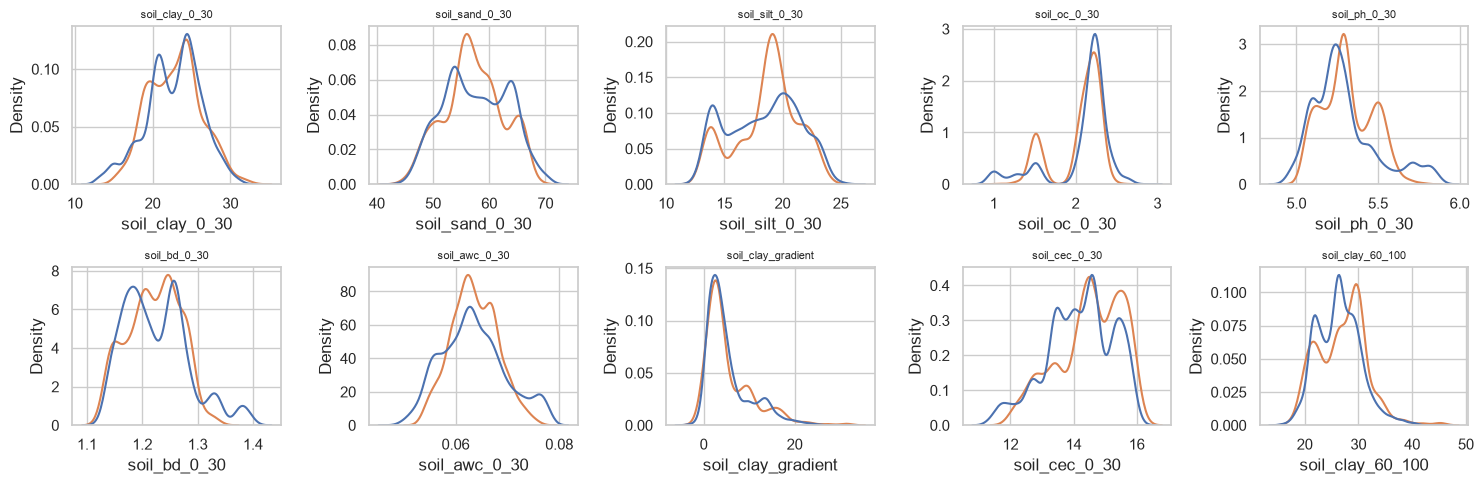

In [22]:
fig, ax = plt.subplots(2, 5, figsize=(15, 5))
for a, c in zip(ax.ravel(), SOIL):
    sns.kdeplot(data=clean, x=c, hue='label', common_norm=False, ax=a, legend=False)
    a.set_title(c, fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
b = clean.dropna(subset=['bench_lhmp_class'])
print('NBRI hazard class AUC:', round(roc_auc_score(b.label, b.bench_lhmp_class), 3))
pd.crosstab(b.bench_lhmp_class, b.label, normalize='index').round(2)

NBRI hazard class AUC: 0.512


label,0,1
bench_lhmp_class,,
1.0,0.82,0.18
2.0,0.80,0.20
3.0,0.81,0.19
4.0,0.79,0.21


## 9. Load the Cleaned Dataset and Define Model Features

In [25]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pathlib import Path

SEED = 42
data_path = Path("../data/processed/static_clean_step1.csv")
if not data_path.exists():
    data_path = Path("data/processed/static_clean_step1.csv")

df = pd.read_csv(data_path)
y = df.label.values

SOIL   = [c for c in df.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']   # drop sand for logistic regression
COORDS = ['meta_lat', 'meta_lon']
print(len(df), 'rows |', int(y.sum()), 'landslides')

5437 rows | 1039 landslides


## 10. Construct Spatial Validation Schemes

In [26]:
# Scheme A: your 3 km blocks (the 'fold' column)
# Scheme B: leave one whole region out (5 regions from k-means on coordinates)
df['region'] = KMeans(5, n_init=10, random_state=SEED).fit_predict(df[COORDS])

idx = np.arange(len(df))
SPLITS = {
    'block3km': [(idx[df.fold != k],   idx[df.fold == k])   for k in sorted(df.fold.unique())],
    'region':   [(idx[df.region != k], idx[df.region == k]) for k in range(5)],
}
for name, sp in SPLITS.items():
    print(name, '| landslides per test fold:', [int(y[te].sum()) for _, te in sp])

block3km | landslides per test fold: [182, 267, 129, 128, 333]
region | landslides per test fold: [91, 309, 366, 103, 170]


### 10.1 Visualise Spatial Validation Partitions
To understand why we do not need a simple random train/test split, let's visualize the spatial clusters (`regions`) created by the K-Means algorithm. Each region represents a geographic fold used in our Leave-One-Region-Out cross-validation.

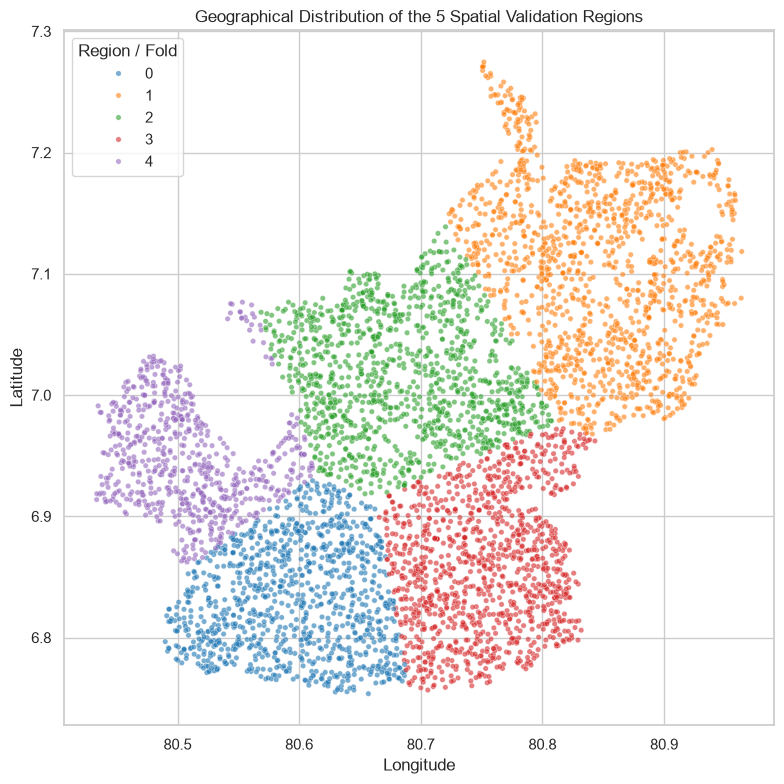

In [27]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df,
    x='meta_lon',
    y='meta_lat',
    hue='region',
    palette='tab10',
    alpha=0.6,
    s=15
)
plt.title('Geographical Distribution of the 5 Spatial Validation Regions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Region / Fold')
plt.tight_layout()
plt.show()

# 11. Define Candidate Models

In [31]:

SEED = 42

# Use the already loaded cleaned dataset
df_clean = df.copy()

# Define the FACTORY dictionary with Logistic Regression, XGBoost, and LightGBM
FACTORY = {
    'LogReg': lambda: make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=3000, random_state=SEED)),
    'XGBoost': lambda: XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.04,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=5,
        eval_metric='logloss',
        n_jobs=2,
        random_state=SEED
    ),
    'LightGBM': lambda: LGBMClassifier(
        n_estimators=250,
        max_depth=3,
        num_leaves=8,
        learning_rate=0.04,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        min_child_samples=40,
        reg_lambda=5,
        verbose=-1,
        n_jobs=2,
        random_state=SEED
    )
}

# Define the feature sets
SOIL = [c for c in df_clean.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']
COORDS = ['meta_lat', 'meta_lon']

# Establish the EXPERIMENTS dictionary (excluding neural networks)
EXPERIMENTS = {
    'LogReg (soil)':          (SOIL_LR, 'LogReg'),
    'XGBoost (soil)':         (SOIL,    'XGBoost'),
    'LightGBM (soil)':        (SOIL,    'LightGBM'),
    'LightGBM (coords only)': (COORDS,  'LightGBM')
}

print("FACTORY and EXPERIMENTS dictionaries have been successfully defined without neural networks.")

FACTORY and EXPERIMENTS dictionaries have been successfully defined without neural networks.


In [32]:


df_clean['region'] = KMeans(5, n_init=10, random_state=SEED).fit_predict(df_clean[COORDS])


idx = np.arange(len(df_clean))
SPLITS = {
    'block3km': [(idx[df_clean.fold != k], idx[df_clean.fold == k]) for k in sorted(df_clean.fold.unique())],
    'region': [(idx[df_clean.region != k], idx[df_clean.region == k]) for k in range(5)],
}

#  Evaluate models on spatial validation schemes
rows = []
for scheme, sp in SPLITS.items():
    # Baseline: NBRI hazard class
    aucs = []
    for _, te in sp:
        t_fold = df_clean.iloc[te].dropna(subset=['bench_lhmp_class'])
        if len(t_fold) > 0 and len(t_fold.label.unique()) > 1:
            aucs.append(roc_auc_score(t_fold.label, t_fold.bench_lhmp_class))
        else:
            aucs.append(np.nan)
    rows.append((scheme, 'NBRI hazard class', np.nanmean(aucs), np.nanstd(aucs), np.nan))

    # Trained models
    for name, (feats, model_name) in EXPERIMENTS.items():
        aucs, aps = [], []
        for tr, te in sp:
            model = FACTORY[model_name]().fit(df_clean.iloc[tr][feats], df_clean.iloc[tr]['label'])
            p = model.predict_proba(df_clean.iloc[te][feats])[:, 1]
            aucs.append(roc_auc_score(df_clean.iloc[te]['label'], p))
            aps.append(average_precision_score(df_clean.iloc[te]['label'], p))
        rows.append((scheme, name, np.mean(aucs), np.std(aucs), np.mean(aps)))

# Create and display results DataFrame
cv_results = pd.DataFrame(rows, columns=['scheme', 'model', 'AUC_mean', 'AUC_std', 'AvgPrecision']).round(3)
print('Base rate (random AvgPrecision):', round(df_clean.label.mean(), 3))
display(cv_results)

Base rate (random AvgPrecision): 0.191


,scheme,model,AUC_mean,AUC_std,AvgPrecision
0,block3km,NBRI hazard class,0.513,0.041,NaN
1,block3km,LogReg (soil),0.604,0.064,0.244
2,block3km,XGBoost (soil),0.742,0.032,0.386
3,block3km,LightGBM (soil),0.735,0.029,0.373
4,block3km,LightGBM (coords only),0.711,0.022,0.359
5,region,NBRI hazard class,0.489,0.023,NaN
6,region,LogReg (soil),0.526,0.103,0.218
7,region,XGBoost (soil),0.575,0.083,0.236
8,region,LightGBM (soil),0.551,0.070,0.229
9,region,LightGBM (coords only),0.549,0.110,0.227


## 12. Baseline Random-Split Model Evaluation

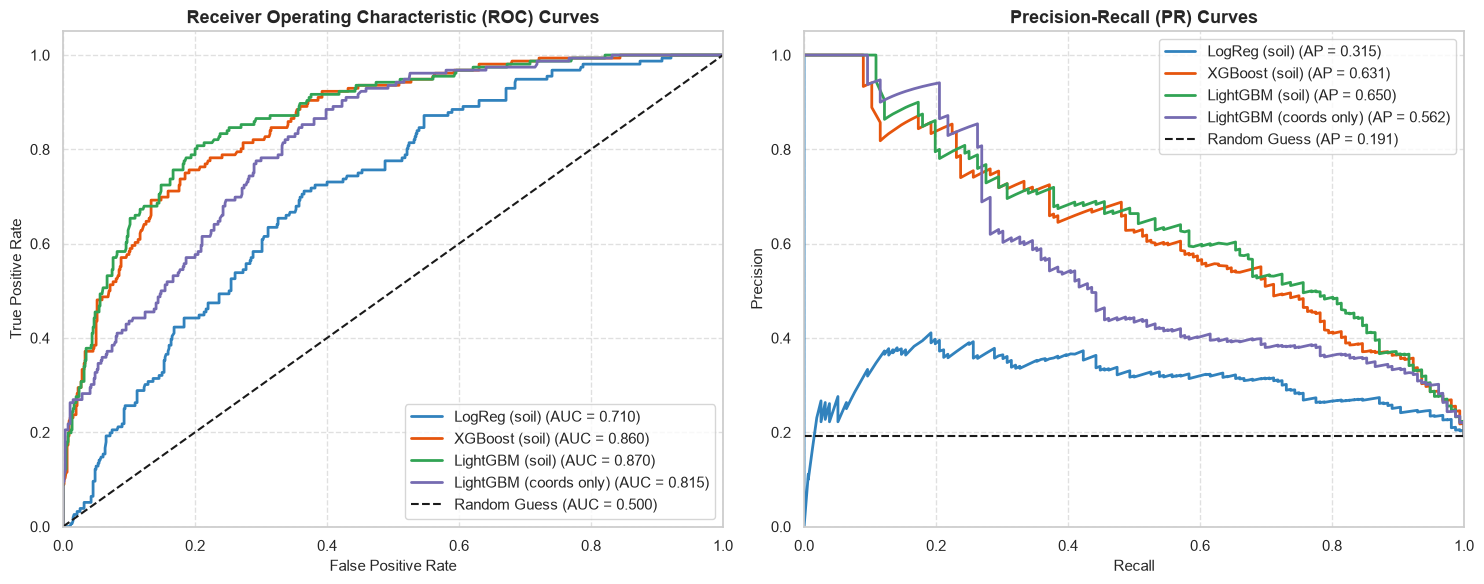

,Model,Test AUC,Test Avg Precision
0,LogReg (soil),0.709600,0.315100
1,XGBoost (soil),0.859700,0.630700
2,LightGBM (soil),0.869900,0.650300
3,LightGBM (coords only),0.815200,0.561900


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, precision_recall_curve



# Reuse the dataset loaded in the previous cell.
# This avoids resolving the CSV path relative to the notebook's current directory.
df_clean = df.copy()


SOIL = [c for c in df_clean.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']

y = df_clean['label'].values

# Split the indices to maintain structural consistency (70% train, 15% validation, 15% test)
idx_train_val, idx_test = train_test_split(
    np.arange(len(df_clean)),
    test_size=0.15,
    random_state=SEED,
    stratify=y
)
idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=15/85,
    random_state=SEED,
    stratify=y[idx_train_val]
)

test_metrics = []
curves = {}


for name, (feats, model_name) in EXPERIMENTS.items():
    # Instantiate and fit the model on the training set
    model = FACTORY[model_name]().fit(df_clean.iloc[idx_train][feats], y[idx_train])

    # Predict probability on the test set
    p_test = model.predict_proba(df_clean.iloc[idx_test][feats])[:, 1]
    y_test = y[idx_test]

    # Compute metrics
    test_auc = roc_auc_score(y_test, p_test)
    test_ap = average_precision_score(y_test, p_test)
    test_metrics.append({'Model': name, 'Test AUC': test_auc, 'Test Avg Precision': test_ap})

    # Compute curves
    fpr, tpr, _ = roc_curve(y_test, p_test)
    precision, recall, _ = precision_recall_curve(y_test, p_test)
    curves[name] = {
        'fpr': fpr, 'tpr': tpr, 'auc': test_auc,
        'precision': precision, 'recall': recall, 'ap': test_ap
    }

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {'LogReg (soil)': '#3182bd', 'XGBoost (soil)': '#e6550d', 'LightGBM (soil)': '#31a354', 'LightGBM (coords only)': '#756bb1'}

# Subplot 1: ROC Curve
for name, data in curves.items():
    axes[0].plot(data['fpr'], data['tpr'], label=f"{name} (AUC = {data['auc']:.3f})", color=colors[name], lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)', lw=1.5)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right", frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Precision-Recall Curve
base_rate = y_test.mean()
for name, data in curves.items():
    axes[1].plot(data['recall'], data['precision'], label=f"{name} (AP = {data['ap']:.3f})", color=colors[name], lw=2)
axes[1].axhline(y=base_rate, color='k', linestyle='--', label=f'Random Guess (AP = {base_rate:.3f})', lw=1.5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall (PR) Curves', fontsize=13, fontweight='bold')
axes[1].legend(loc="upper right", frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


df_summary = pd.DataFrame(test_metrics).round(4)
display(df_summary.style.background_gradient(cmap='Greens', subset=['Test AUC', 'Test Avg Precision']))

### 12.1 Compare Training and Test Performance

In [36]:
from pathlib import Path

# 1. Load clean dataset
data_path = Path("../data/processed/static_clean_step1.csv")

if not data_path.exists():
    data_path = Path("data/processed/static_clean_step1.csv")

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found. Checked:\n"
        f"- {Path('../data/processed/static_clean_step1.csv').resolve()}\n"
        f"- {Path('data/processed/static_clean_step1.csv').resolve()}"
    )

df_clean = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path.resolve()}")
y_full = df_clean['label'].values

# 2. Define features
SOIL = [c for c in df_clean.columns if c.startswith('soil_')]
SOIL_LR = [c for c in SOIL if c != 'soil_sand_0_30']

# 3. Use train/test indices defined previously
X_train_full = df_clean.iloc[idx_train]
y_train_full = y_full[idx_train]
X_test_full = df_clean.iloc[idx_test]
y_test_full = y_full[idx_test]

# 4. Train models and evaluate AUC-ROC on train and test splits
results_auc = []

for name, (feats, model_name) in EXPERIMENTS.items():
    if 'coords' in name:
        continue  # Only evaluate models on soil features as requested

    # Instantiate and fit
    model = FACTORY[model_name]().fit(X_train_full[feats], y_train_full)

    # Predict probabilities
    p_train = model.predict_proba(X_train_full[feats])[:, 1]
    p_test = model.predict_proba(X_test_full[feats])[:, 1]

    # Calculate AUCs
    train_auc = roc_auc_score(y_train_full, p_train)
    test_auc = roc_auc_score(y_test_full, p_test)

    results_auc.append({
        'Model': name,
        'Train AUC-ROC': train_auc,
        'Test AUC-ROC': test_auc,
        'Difference (Overfitting Gap)': train_auc - test_auc
    })

# 5. Display results
df_auc_summary = pd.DataFrame(results_auc).round(4)
display(df_auc_summary)

Loaded dataset from: C:\Users\Sadumina Rathnayaka\Desktop\Model\data\processed\static_clean_step1.csv


,Model,Train AUC-ROC,Test AUC-ROC,Difference (Overfitting Gap)
0,LogReg (soil),0.6726,0.7096,-0.0370
1,XGBoost (soil),0.9010,0.8597,0.0413
2,LightGBM (soil),0.9046,0.8699,0.0347


### 12.2 Assess Potential Overfitting

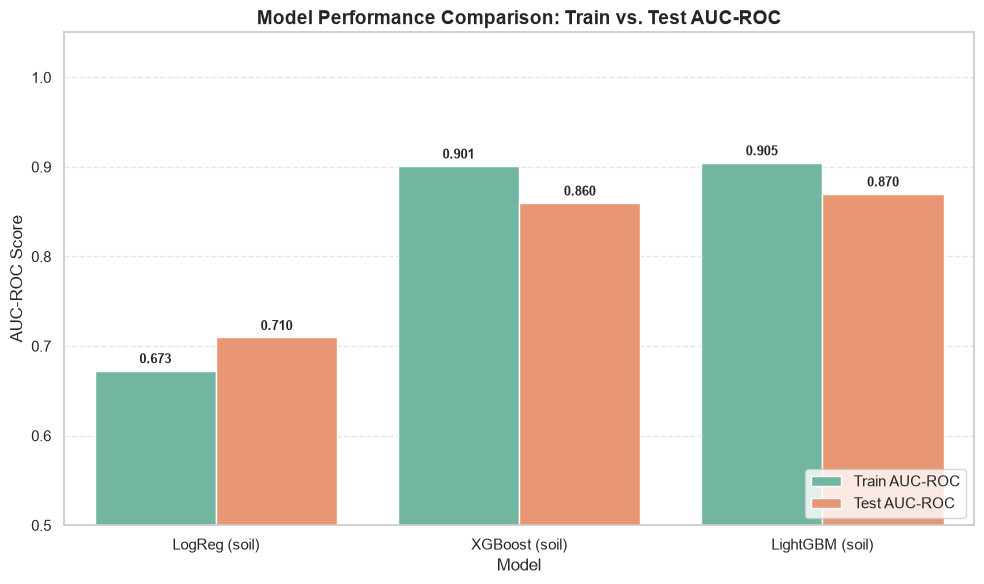

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
df_plot = df_auc_summary.melt(
    id_vars='Model',
    value_vars=['Train AUC-ROC', 'Test AUC-ROC'],
    var_name='Split',
    value_name='AUC-ROC'
)

# Plot side-by-side bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Model', y='AUC-ROC', hue='Split', palette='Set2')

plt.ylim(0.5, 1.05)
plt.title('Model Performance Comparison: Train vs. Test AUC-ROC', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('AUC-ROC Score', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

# Add values on top of the bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center',
                            xytext=(0, 8),
                            textcoords='offset points',
                            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 12.3 Summarise Baseline Model Performance


,Model,Train AUC-ROC,Validation AUC-ROC,Test AUC-ROC
0,LogReg (soil),0.6726,0.6579,0.7096
1,XGBoost (soil),0.9010,0.8568,0.8597
2,LightGBM (soil),0.9046,0.8600,0.8699


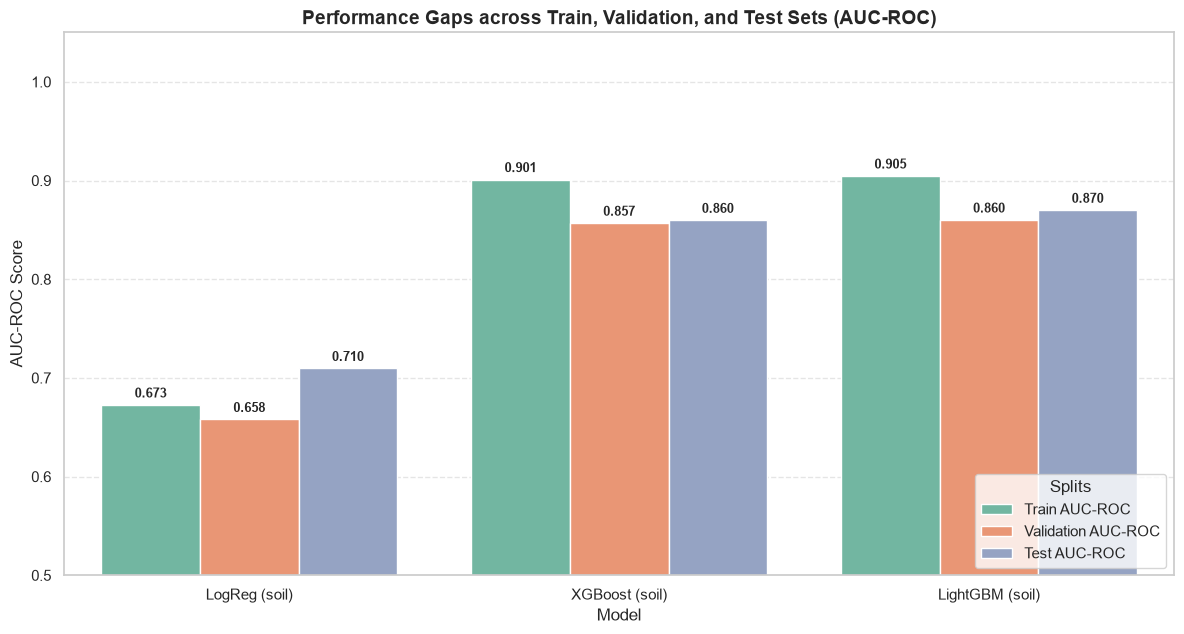

In [38]:
# 1. Prepare data holders
results_all_splits = []

# Define the splits mapped from previously defined indices
splits = {
    'Train': (idx_train, 'Train'),
    'Validation': (idx_val, 'Validation'),
    'Test': (idx_test, 'Test')
}

# 2. Extract AUC-ROC scores across all three splits
for name, (feats, model_name) in EXPERIMENTS.items():
    if 'coords' in name:
        continue  # Keep focused on soil features

    # Fit on training set
    model = FACTORY[model_name]().fit(df_clean.iloc[idx_train][feats], y_full[idx_train])

    row = {'Model': name}
    for split_name, (idx_split, _) in splits.items():
        p = model.predict_proba(df_clean.iloc[idx_split][feats])[:, 1]
        auc = roc_auc_score(y_full[idx_split], p)
        row[f'{split_name} AUC-ROC'] = auc

    results_all_splits.append(row)

df_splits_summary = pd.DataFrame(results_all_splits).round(4)
display(df_splits_summary)

# 3. Reshape for visualization
df_plot_three = df_splits_summary.melt(
    id_vars='Model',
    value_vars=['Train AUC-ROC', 'Validation AUC-ROC', 'Test AUC-ROC'],
    var_name='Split',
    value_name='AUC-ROC'
)

# 4. Generate the graph
plt.figure(figsize=(12, 6.5))
sns.barplot(data=df_plot_three, x='Model', y='AUC-ROC', hue='Split', palette='Set2')

plt.ylim(0.5, 1.05)
plt.title('Performance Gaps across Train, Validation, and Test Sets (AUC-ROC)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('AUC-ROC Score', fontsize=12)
plt.legend(loc='lower right', frameon=True, title='Splits')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

# Annotate scores
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center',
                            xytext=(0, 8),
                            textcoords='offset points',
                            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Spatial Susceptibility Evaluation

The objective of this stage is to estimate how well the models generalise to geographically separated locations. Spatial validation is treated as the primary evaluation because random splitting can place nearby observations in both the training and test sets.

The principal output is a spatial susceptibility estimate for each location. The following analyses assess whether the model can rank locations reliably, whether its probabilities are calibrated, and how its performance changes when geographic separation is enforced.

In [40]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

threshold_rows = []

y_val = y_full[idx_val]
validation_model = FACTORY["LightGBM"]().fit(
    df_clean.iloc[idx_train][SOIL],
    y_full[idx_train],
)
p_val = validation_model.predict_proba(
    df_clean.iloc[idx_val][SOIL]
)[:, 1]

for threshold in thresholds:

    y_pred = (p_val >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred,
        labels=[0, 1],
    ).ravel()

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, y_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, y_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, y_pred, zero_division=0
        ),
        "specificity": tn / (tn + fp),
        "false_alarm_rate": fp / (fp + tn),
        "balanced_accuracy": balanced_accuracy_score(
            y_val, y_pred
        ),
        "mcc": matthews_corrcoef(y_val, y_pred),
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.round(3))

,threshold,precision,recall,f1,specificity,false_alarm_rate,balanced_accuracy,mcc
0,0.1,0.301,0.942,0.456,0.482,0.518,0.712,0.340
1,0.2,0.416,0.776,0.541,0.742,0.258,0.759,0.425
2,0.3,0.550,0.673,0.605,0.870,0.130,0.771,0.504
3,0.4,0.687,0.590,0.634,0.936,0.064,0.763,0.558
4,0.5,0.812,0.442,0.573,0.976,0.024,0.709,0.538


### 13.1 Use the Existing Spatial Fold Assignments

In [43]:
# Keep this fold untouched until final evaluation
# Use the spatial fold IDs already stored in the cleaned dataset
if "fold" not in df_clean.columns:
    raise KeyError("The dataset must contain a 'fold' column.")

spatial_folds = sorted(df_clean["fold"].dropna().unique().tolist())

if len(spatial_folds) < 2:
    raise ValueError("At least two spatial folds are required.")

TEST_FOLD = spatial_folds[-1]

validation_folds = [
    fold_id for fold_id in spatial_folds
    if fold_id != TEST_FOLD
]

print("Validation folds:", validation_folds)
print("Test fold:", TEST_FOLD)

Validation folds: [0, 1, 2, 3]
Test fold: 4


In [44]:
oof_probability = np.full(len(df_clean), np.nan)

for validation_fold in validation_folds:
    train_mask = (
        (df_clean["fold"] != validation_fold)
        & (df_clean["fold"] != TEST_FOLD)
    )

    validation_mask = df_clean["fold"] == validation_fold

    model = FACTORY["LightGBM"]()

    model.fit(
        df_clean.loc[train_mask, SOIL],
        y_full[train_mask],
    )

    oof_probability[validation_mask] = model.predict_proba(
        df_clean.loc[validation_mask, SOIL]
    )[:, 1]

# Confirm every validation observation received a prediction
oof_mask = ~np.isnan(oof_probability)

print("OOF observations:", oof_mask.sum())
print("Expected observations:", (df_clean["fold"] != TEST_FOLD).sum())

if not np.all(oof_mask[df_clean["fold"] != TEST_FOLD]):
    raise ValueError("Some spatial validation rows do not have predictions.")

OOF observations: 4334
Expected observations: 4334


### 13.2 Select the Classification Threshold from Spatial Predictions

In [45]:
y_oof = y_full[oof_mask]
p_oof = oof_probability[oof_mask]

thresholds = np.arange(0.10, 0.91, 0.05)

spatial_threshold_rows = []

for threshold in thresholds:
    y_pred = (p_oof >= threshold).astype(int)

    spatial_threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(
            y_oof,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_oof,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_oof,
            y_pred,
            zero_division=0,
        ),
    })

spatial_threshold_results = (
    pd.DataFrame(spatial_threshold_rows)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

display(spatial_threshold_results.round(4))

,threshold,precision,recall,f1
0,0.10,0.2329,0.7663,0.3572
1,0.15,0.2427,0.5992,0.3454
2,0.20,0.2506,0.4533,0.3227
3,0.25,0.2748,0.3414,0.3045
4,0.30,0.2888,0.2635,0.2756
5,0.35,0.3056,0.2181,0.2545
6,0.40,0.2784,0.1530,0.1974
7,0.45,0.3180,0.1374,0.1919
8,0.50,0.3265,0.1133,0.1682
9,0.55,0.3254,0.0779,0.1257


In [47]:
train_mask = df_clean["fold"] != TEST_FOLD
test_mask = df_clean["fold"] == TEST_FOLD

final_model = FACTORY["LightGBM"]()

final_model.fit(
    df_clean.loc[train_mask, SOIL],
    y_full[train_mask],
)

p_test = final_model.predict_proba(
    df_clean.loc[test_mask, SOIL]
)[:, 1]

y_test = y_full[test_mask]
selected_row = spatial_threshold_results.loc[
    spatial_threshold_results["f1"].idxmax()
]
SELECTED_THRESHOLD = float(selected_row["threshold"])

y_test_pred = (p_test >= SELECTED_THRESHOLD).astype(int)

print(f"Selected threshold: {SELECTED_THRESHOLD:.2f}")
print(f"Predicted susceptible locations: {y_test_pred.sum():,}")

Selected threshold: 0.10
Predicted susceptible locations: 712


### 13.3 Evaluate Classification Errors with a Confusion Matrix

In [49]:
from sklearn.metrics import brier_score_loss

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1],
).ravel()

final_metrics = pd.DataFrame([{
    "model": "LightGBM",
    "test_fold": TEST_FOLD,
    "threshold": SELECTED_THRESHOLD,
    "roc_auc": roc_auc_score(y_test, p_test),
    "average_precision": average_precision_score(y_test, p_test),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred, zero_division=0),
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "true_positives": tp,
    "brier_score": brier_score_loss(y_test, p_test),
}])

display(final_metrics.round(4))

,model,test_fold,threshold,roc_auc,average_precision,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,brier_score
0,LightGBM,4,0.1,0.7722,0.5871,0.427,0.9129,0.5818,362,408,29,304,0.1897


In [50]:
from pathlib import Path

Path("../outputs/tables").mkdir(parents=True, exist_ok=True)

final_metrics.to_csv(
    "../outputs/tables/static_final_spatial_metrics.csv",
    index=False,
)

spatial_threshold_results.to_csv(
    "../outputs/tables/static_spatial_threshold_results.csv",
    index=False,
)

### 13.4 Assess Probability Calibration

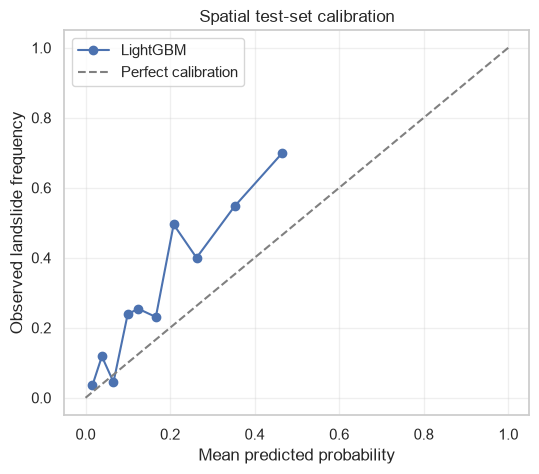

In [51]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="LightGBM",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed landslide frequency")
plt.title("Spatial test-set calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 13.5 Convert Probabilities into Susceptibility Categories

In [53]:
risk_bins = [-np.inf, 0.20, 0.40, 0.60, 0.80, np.inf]

risk_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High",
]

test_results = df_clean.loc[test_mask].copy()

test_results["predicted_probability"] = p_test

test_results["risk_level"] = pd.cut(
    test_results["predicted_probability"],
    bins=risk_bins,
    labels=risk_labels,
    include_lowest=True,
)

test_results["predicted_label"] = y_test_pred

display(
    test_results[
        [
            "meta_lat",
            "meta_lon",
            "predicted_probability",
            "risk_level",
            "label",
            "predicted_label",
        ]
    ].head(10)
)

,meta_lat,meta_lon,predicted_probability,risk_level,label,predicted_label
0,7.098072,80.756045,0.098295,Very Low,1,0
1,7.109057,80.746482,0.139207,Very Low,1,1
2,7.099661,80.755744,0.098295,Very Low,1,0
3,7.098072,80.753045,0.098295,Very Low,1,0
5,6.977065,80.749854,0.258583,Low,1,1
11,7.030550,80.682458,0.260414,Low,1,1
12,7.116142,80.791955,0.544724,Moderate,1,1
14,7.070319,80.803366,0.213560,Low,1,1
17,6.967873,80.783696,0.462590,Moderate,1,1
20,7.082207,80.779170,0.112236,Very Low,1,1


### 13.6 Inspect the Susceptibility Category Distribution


In [54]:
risk_summary = (
    test_results["risk_level"]
    .value_counts()
    .reindex(risk_labels)
    .rename_axis("risk_level")
    .reset_index(name="sample_count")
)

risk_summary["percentage"] = (
    risk_summary["sample_count"]
    / risk_summary["sample_count"].sum()
    * 100
)

display(risk_summary.round(2))

,risk_level,sample_count,percentage
0,Very Low,695,63.01
1,Low,315,28.56
2,Moderate,89,8.07
3,High,4,0.36
4,Very High,0,0.00


### 13.7 Compare Logistic Regression, XGBoost, and LightGBM

In [58]:
model_results = []

model_specs = {
    "Logistic Regression": "LogReg",
    "XGBoost": "XGBoost",
    "LightGBM": "LightGBM",
}

for display_name, factory_name in model_specs.items():
    model = FACTORY[factory_name]()

    model.fit(
        df_clean.loc[train_mask, SOIL],
        y_full[train_mask],
    )

    probability = model.predict_proba(
        df_clean.loc[test_mask, SOIL]
    )[:, 1]

    prediction = (
        probability >= SELECTED_THRESHOLD
    ).astype(int)

    model_results.append({
        "model": display_name,
        "roc_auc": roc_auc_score(
            y_test,
            probability,
        ),
        "average_precision": average_precision_score(
            y_test,
            probability,
        ),
        "precision": precision_score(
            y_test,
            prediction,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test,
            prediction,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test,
            prediction,
            zero_division=0,
        ),
        "brier_score": brier_score_loss(
            y_test,
            probability,
        ),
    })

final_model_comparison = pd.DataFrame(model_results)

display(
    final_model_comparison
    .sort_values(
        "average_precision",
        ascending=False,
    )
    .round(4)
)

,model,roc_auc,average_precision,precision,recall,f1,brier_score
1,XGBoost,0.7776,0.5919,0.4365,0.8979,0.5874,0.1884
2,LightGBM,0.7722,0.5871,0.4270,0.9129,0.5818,0.1897
0,Logistic Regression,0.6842,0.4408,0.3496,0.9910,0.5168,0.2125


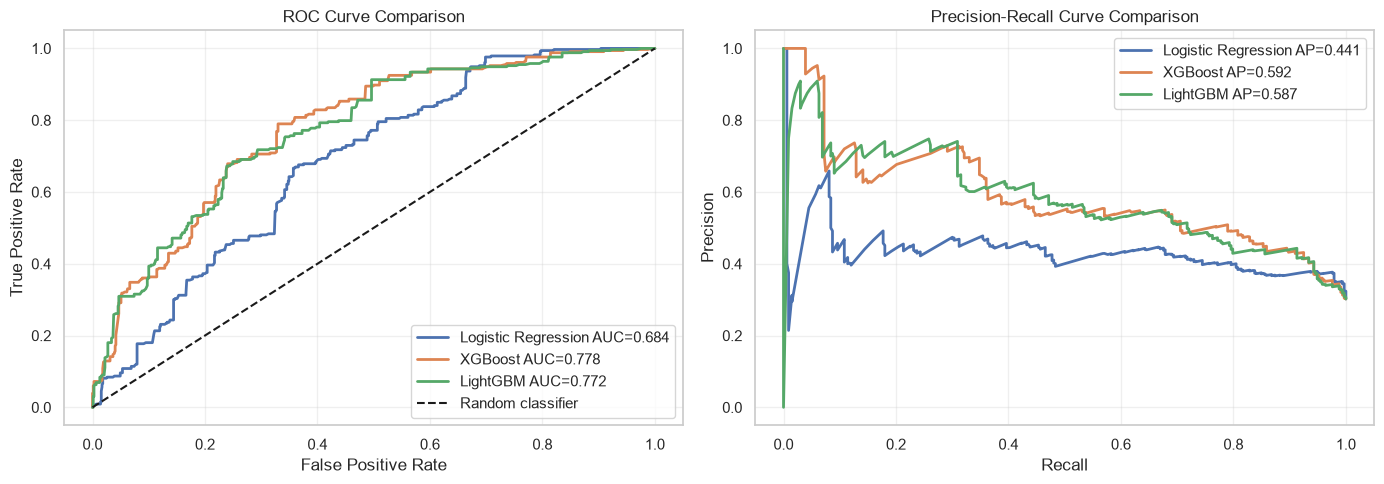

In [61]:
plot_data = {}

for display_name, factory_name in model_specs.items():
    model = FACTORY[factory_name]()

    model.fit(
        df_clean.loc[train_mask, SOIL],
        y_full[train_mask],
    )

    plot_data[display_name] = {
        "probability": model.predict_proba(
            df_clean.loc[test_mask, SOIL]
        )[:, 1]
    }

y_test = y_full[test_mask]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

for display_name, values in plot_data.items():

    probability = values["probability"]

    # ROC curve
    fpr, tpr, _ = roc_curve(
        y_test,
        probability,
    )

    roc_auc = roc_auc_score(
        y_test,
        probability,
    )

    axes[0].plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{display_name} AUC={roc_auc:.3f}",
    )

    # Precision-recall curve
    precision, recall, _ = precision_recall_curve(
        y_test,
        probability,
    )

    average_precision = average_precision_score(
        y_test,
        probability,
    )

    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=f"{display_name} AP={average_precision:.3f}",
    )

# ROC reference line
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random classifier",
)

axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13.8 Visualise Metric Differences

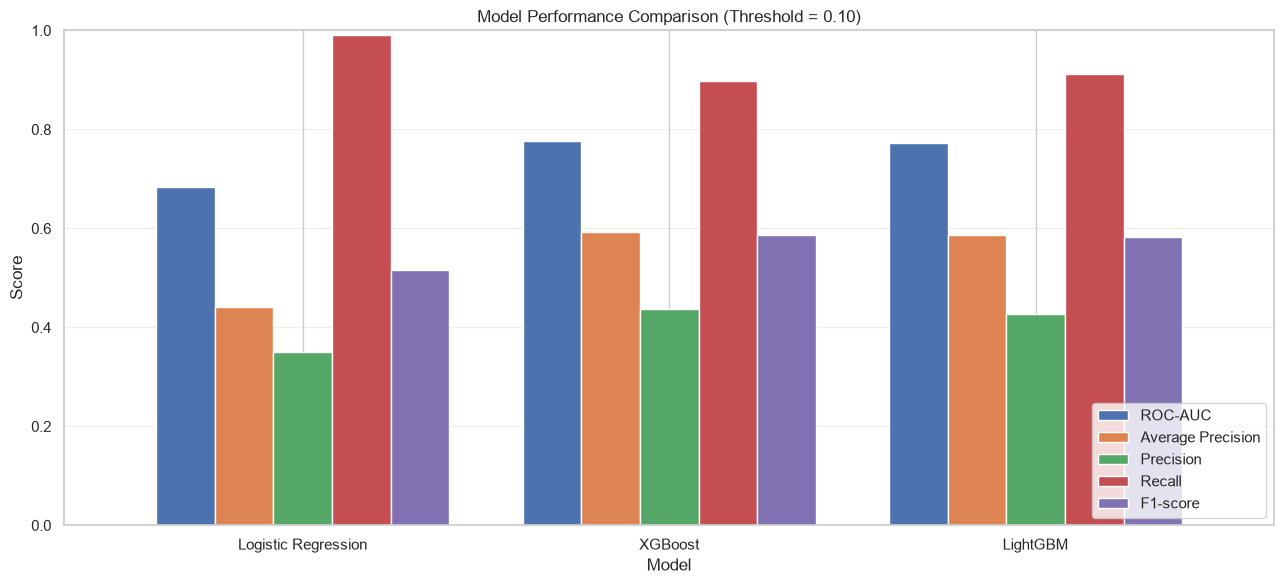

In [62]:
metric_columns = [
    "roc_auc",
    "average_precision",
    "precision",
    "recall",
    "f1",
]

metric_labels = {
    "roc_auc": "ROC-AUC",
    "average_precision": "Average Precision",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
}

plot_metrics = (
    final_model_comparison
    .set_index("model")[metric_columns]
    .rename(columns=metric_labels)
)

ax = plot_metrics.plot(
    kind="bar",
    figsize=(13, 6),
    ylim=(0, 1),
    width=0.8,
)

ax.set_title(
    f"Model Performance Comparison "
    f"(Threshold = {SELECTED_THRESHOLD:.2f})"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 13.9 Compare Probability Error Using the Brier Score

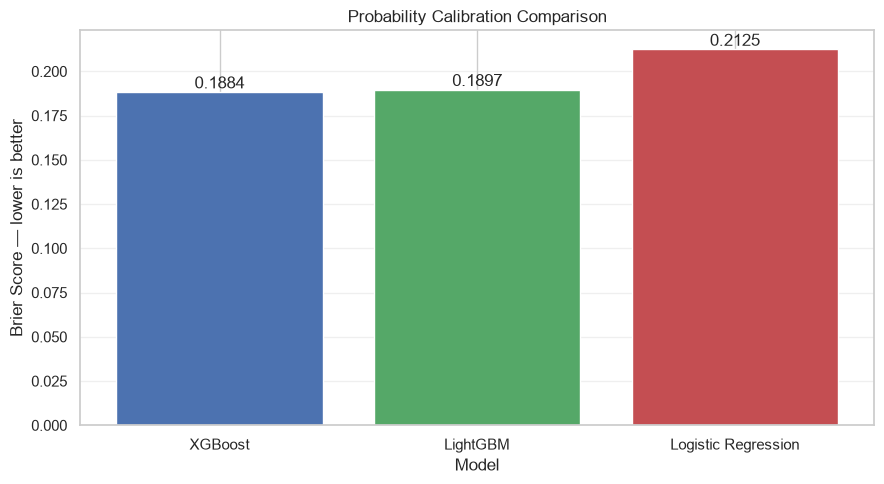

In [63]:
brier_plot = (
    final_model_comparison
    .sort_values("brier_score")
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    brier_plot["model"],
    brier_plot["brier_score"],
    color=["#4C72B0", "#55A868", "#C44E52"],
)

plt.title("Probability Calibration Comparison")
plt.xlabel("Model")
plt.ylabel("Brier Score — lower is better")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.4f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### 13.10 Compare Calibration Curves

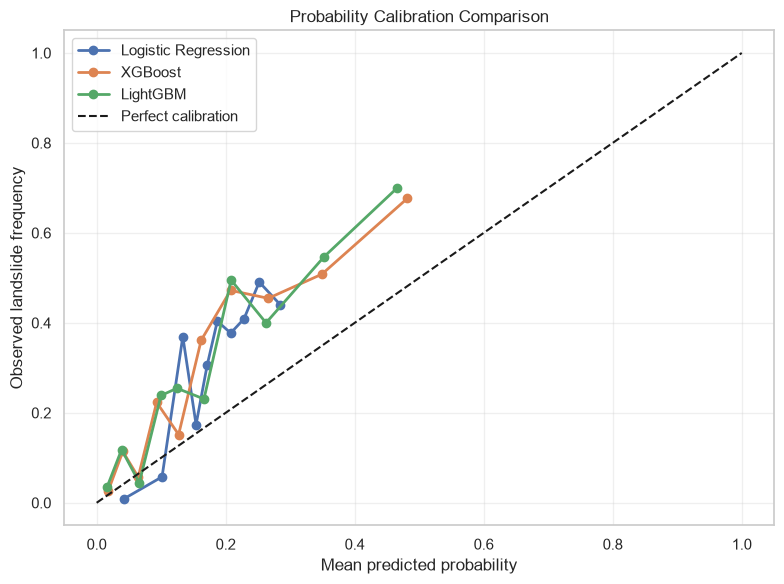

In [64]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 6))

for display_name, values in plot_data.items():

    probability = values["probability"]

    observed_probability, predicted_probability = calibration_curve(
        y_test,
        probability,
        n_bins=10,
        strategy="quantile",
    )

    plt.plot(
        predicted_probability,
        observed_probability,
        marker="o",
        linewidth=2,
        label=display_name,
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Perfect calibration",
)

plt.title("Probability Calibration Comparison")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed landslide frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
from pathlib import Path
import joblib

output_tables = Path("../outputs/tables")
output_tables.mkdir(parents=True, exist_ok=True)


final_model_comparison.to_csv(
    output_tables / "static_model_comparison.csv",
    index=False,
)

test_results.to_csv(
    output_tables / "static_test_predictions.csv",
    index=False,
)

risk_summary.to_csv(
    output_tables / "static_risk_summary.csv",
    index=False,
)

# 14. Compare Validation Strategies


In [67]:


from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
)

COMPARISON_THRESHOLD = SELECTED_THRESHOLD

comparison_rows = []

### 14.1 Random-Split Evaluation

In [68]:
# Existing random split indices
# idx_train and idx_test must already exist

random_model = FACTORY["LightGBM"]()

random_model.fit(
    df_clean.iloc[idx_train][SOIL],
    y_full[idx_train],
)

random_probability = random_model.predict_proba(
    df_clean.iloc[idx_test][SOIL]
)[:, 1]

random_prediction = (
    random_probability >= COMPARISON_THRESHOLD
).astype(int)

y_random_test = y_full[idx_test]

comparison_rows.append({
    "validation": "Random split",
    "model": "LightGBM",
    "n_test": len(y_random_test),
    "accuracy": accuracy_score(
        y_random_test,
        random_prediction,
    ),
    "roc_auc": roc_auc_score(
        y_random_test,
        random_probability,
    ),
    "average_precision": average_precision_score(
        y_random_test,
        random_probability,
    ),
    "precision": precision_score(
        y_random_test,
        random_prediction,
        zero_division=0,
    ),
    "recall": recall_score(
        y_random_test,
        random_prediction,
        zero_division=0,
    ),
    "f1": f1_score(
        y_random_test,
        random_prediction,
        zero_division=0,
    ),
    "brier_score": brier_score_loss(
        y_random_test,
        random_probability,
    ),
})

### 14.2 Spatial Block Cross-Validation

In [69]:
spatial_probability = np.full(
    len(df_clean),
    np.nan,
)

spatial_folds = sorted(
    df_clean["fold"].dropna().unique()
)

for validation_fold in spatial_folds:

    train_mask_spatial = (
        df_clean["fold"] != validation_fold
    )

    validation_mask_spatial = (
        df_clean["fold"] == validation_fold
    )

    spatial_model = FACTORY["LightGBM"]()

    spatial_model.fit(
        df_clean.loc[
            train_mask_spatial,
            SOIL,
        ],
        y_full[train_mask_spatial],
    )

    spatial_probability[
        validation_mask_spatial
    ] = spatial_model.predict_proba(
        df_clean.loc[
            validation_mask_spatial,
            SOIL,
        ]
    )[:, 1]

spatial_valid = ~np.isnan(
    spatial_probability
)

y_spatial = y_full[spatial_valid]
p_spatial = spatial_probability[spatial_valid]

pred_spatial = (
    p_spatial >= COMPARISON_THRESHOLD
).astype(int)

comparison_rows.append({
    "validation": "Spatial block CV",
    "model": "LightGBM",
    "n_test": len(y_spatial),
    "accuracy": accuracy_score(
        y_spatial,
        pred_spatial,
    ),
    "roc_auc": roc_auc_score(
        y_spatial,
        p_spatial,
    ),
    "average_precision": average_precision_score(
        y_spatial,
        p_spatial,
    ),
    "precision": precision_score(
        y_spatial,
        pred_spatial,
        zero_division=0,
    ),
    "recall": recall_score(
        y_spatial,
        pred_spatial,
        zero_division=0,
    ),
    "f1": f1_score(
        y_spatial,
        pred_spatial,
        zero_division=0,
    ),
    "brier_score": brier_score_loss(
        y_spatial,
        p_spatial,
    ),
})

### 14.3 Unseen-Region Cross-Validation

In [71]:
region_probability = np.full(
    len(df_clean),
    np.nan,
)

if "region" not in df_clean.columns:
    region_sources = [
        value
        for value in globals().values()
        if isinstance(value, pd.DataFrame)
        and "region" in value.columns
        and df_clean.index.isin(value.index).all()
    ]

    if not region_sources:
        raise KeyError(
            "No dataframe containing a 'region' column was found."
        )

    region_source = region_sources[0]

    df_clean = df_clean.copy()
    df_clean["region"] = region_source.loc[
        df_clean.index,
        "region",
    ]

regions = sorted(
    df_clean["region"].dropna().unique()
)

for validation_region in regions:

    train_mask_region = (
        df_clean["region"] != validation_region
    )

    validation_mask_region = (
        df_clean["region"] == validation_region
    )

    region_model = FACTORY["LightGBM"]()

    region_model.fit(
        df_clean.loc[
            train_mask_region,
            SOIL,
        ],
        y_full[train_mask_region],
    )

    region_probability[
        validation_mask_region
    ] = region_model.predict_proba(
        df_clean.loc[
            validation_mask_region,
            SOIL,
        ]
    )[:, 1]

region_valid = ~np.isnan(
    region_probability
)

y_region = y_full[region_valid]
p_region = region_probability[region_valid]

pred_region = (
    p_region >= COMPARISON_THRESHOLD
).astype(int)

comparison_rows.append({
    "validation": "Unseen-region CV",
    "model": "LightGBM",
    "n_test": len(y_region),
    "accuracy": accuracy_score(
        y_region,
        pred_region,
    ),
    "roc_auc": roc_auc_score(
        y_region,
        p_region,
    ),
    "average_precision": average_precision_score(
        y_region,
        p_region,
    ),
    "precision": precision_score(
        y_region,
        pred_region,
        zero_division=0,
    ),
    "recall": recall_score(
        y_region,
        pred_region,
        zero_division=0,
    ),
    "f1": f1_score(
        y_region,
        pred_region,
        zero_division=0,
    ),
    "brier_score": brier_score_loss(
        y_region,
        p_region,
    ),
})

In [72]:
validation_comparison = (
    pd.DataFrame(comparison_rows)
    .round(4)
)

display(validation_comparison)

,validation,model,n_test,accuracy,roc_auc,average_precision,precision,recall,f1,brier_score
0,Random split,LightGBM,816,0.5944,0.8699,0.6503,0.3134,0.9423,0.4704,0.1059
1,Spatial block CV,LightGBM,5437,0.5196,0.7397,0.3537,0.2728,0.9086,0.4196,0.1412
2,Unseen-region CV,LightGBM,5437,0.4905,0.4832,0.1853,0.1805,0.4706,0.2609,0.1738


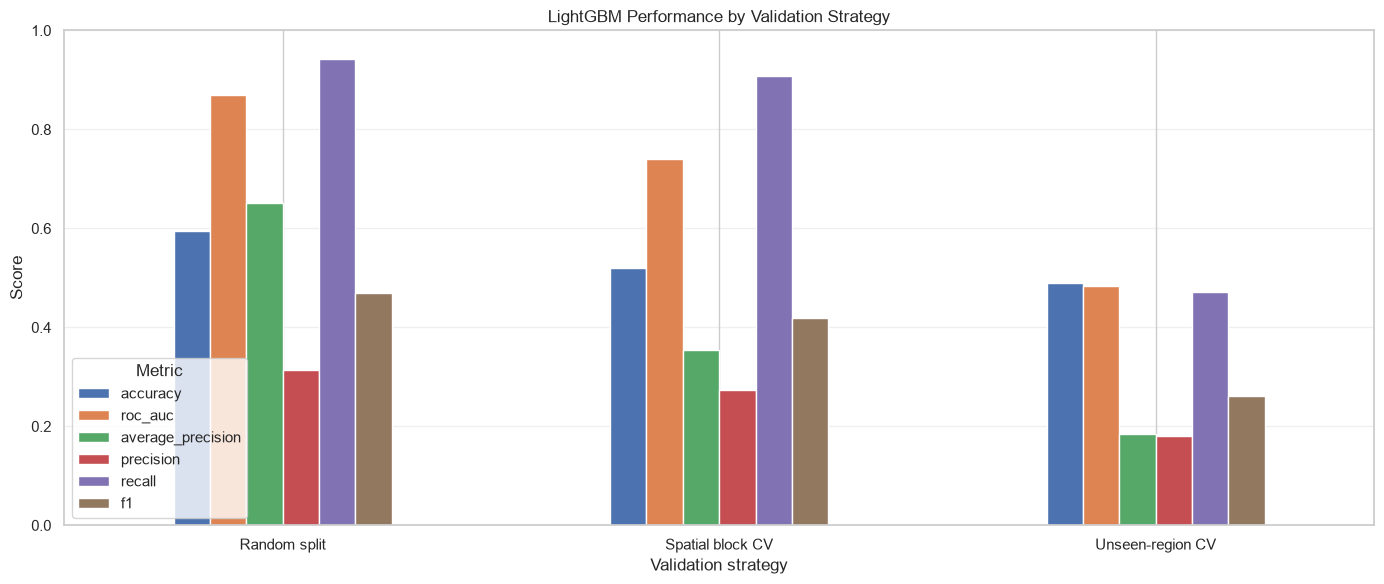

In [73]:
import matplotlib.pyplot as plt

plot_metrics = [
    "accuracy",
    "roc_auc",
    "average_precision",
    "precision",
    "recall",
    "f1",
]

validation_comparison.set_index(
    "validation"
)[plot_metrics].plot(
    kind="bar",
    figsize=(14, 6),
    ylim=(0, 1),
)

plt.title(
    "LightGBM Performance by Validation Strategy"
)

plt.xlabel("Validation strategy")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(
    title="Metric",
    loc="lower left",
)

plt.tight_layout()
plt.show()